In [1]:
import glob
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt

# Instantiate instrument

PyReduce defines instruments as subclasses of `pyreduce.instruments.Instrument` which live as packages in `pyreduce.instruments`. It contains methods to load, parse, and categorize raw FITS files based on the header keyword
information in the instrument config. Most methods can be used directly, or overriden if needed. We have created an instrument package for ZSHOOTER that lives in this repo (`zshooter-drp/src/zsdrp/ZSHOOTER`), and overriden some
methods to load it correctly.

In [2]:
### Method 2: import zshooter instrument class directly that correctly loads config info
from ZSHOOTER import ZSHOOTER
zs = ZSHOOTER()

Another way to instantiate a custom instrument class on the fly is also available in PyReduce, which only takes the path to instrument yaml config as input.

In [3]:
### Method 1: use instant custom instrument creation
from pyreduce.instruments.common import create_custom_instrument
zs = create_custom_instrument(name='ZSHOOTER', extension=1, info='ZSHOOTER/config.yaml')

# Load files

In [4]:
rawdir = "../../../zs-scopesim/dev_notebooks/sims"
outdir = rawdir+"/reduced"

files = {}
for chan in zs.config.channels:
    files[chan] = {}
    files[chan]['bias'] = sorted(glob.glob(f'{rawdir}/bias_{chan}*.fits'))
    files[chan]['flat'] = sorted(glob.glob(f'{rawdir}/flat_{chan}*.fits'))
    files[chan]['arcs'] = sorted(glob.glob(f'{rawdir}/arcs_{chan}*.fits'))
    files[chan]['star'] = sorted(glob.glob(f'{rawdir}/star_{chan}.fits'))
    files[chan]['sn'] = sorted(glob.glob(f'{rawdir}/sn_{chan}*.fits'))

In [5]:
files

{'B': {'bias': ['../../../zs-scopesim/dev_notebooks/sims/bias_B.fits'],
  'flat': ['../../../zs-scopesim/dev_notebooks/sims/flat_B.fits'],
  'arcs': ['../../../zs-scopesim/dev_notebooks/sims/arcs_B.fits'],
  'star': ['../../../zs-scopesim/dev_notebooks/sims/star_B.fits'],
  'sn': ['../../../zs-scopesim/dev_notebooks/sims/sn_B.fits']},
 'G': {'bias': ['../../../zs-scopesim/dev_notebooks/sims/bias_G.fits'],
  'flat': ['../../../zs-scopesim/dev_notebooks/sims/flat_G.fits'],
  'arcs': ['../../../zs-scopesim/dev_notebooks/sims/arcs_G.fits'],
  'star': ['../../../zs-scopesim/dev_notebooks/sims/star_G.fits'],
  'sn': ['../../../zs-scopesim/dev_notebooks/sims/sn_G.fits']},
 'R': {'bias': ['../../../zs-scopesim/dev_notebooks/sims/bias_R.fits'],
  'flat': ['../../../zs-scopesim/dev_notebooks/sims/flat_R.fits'],
  'arcs': ['../../../zs-scopesim/dev_notebooks/sims/arcs_R.fits'],
  'star': ['../../../zs-scopesim/dev_notebooks/sims/star_R.fits'],
  'sn': ['../../../zs-scopesim/dev_notebooks/sims/sn_

# Load reduction settings (input params for steps)

For the next steps, we need to set parameter/kwarg values for each step, tuned for the instrument data.

There are a set of default settings for each step stored in `pyreduce.defaults.settings.json`. Inside instrument package, `settings.json` inherits from the defaults and
contains entries that override specific parameters for that instrument. There can be multiple settings files, inheriting from each other for different channels.

In [6]:
from utils import config_loader
settings_cfg = config_loader('ZSHOOTER/settings.yaml')

In [7]:
settings_cfg['flat']

{'bias_scaling': 'exposure_time',
 'norm_scaling': 'none',
 'plot': False,
 'plot_title': 'Flat'}

# Preprocessing steps

For combining bias images, two core methods are available:
- `combine_bias`: if all images are biases
- `combine_polynomial`: if images are biases and darks

Preproc of other image types is handled by `combine_calibrate`. It corrects them by the provided master bias, and normalized flat, and returns combined image.

In [8]:
from pyreduce.reduce import combine_bias, combine_calibrate

cals = {}
for chan in zs.config.channels:
    # create master bias
    bias, bhead = combine_bias(files[chan]['bias'], instrument=zs, channel=chan)

    # create master flat
    cfg = settings_cfg.get('flat')
    flat, fhead = combine_calibrate(files[chan]['flat'], instrument=zs, channel=chan, bias=bias, bhead=bhead, **cfg)

    # save to cals dict
    cals[chan] = {'mbias': [bias, bhead], 'mflat': [flat, fhead]}
    print(f'Done with channel {chan}')

WARNING - No exposure time set in bias, using number of files instead
Done with channel B
WARNING - No exposure time set in bias, using number of files instead
Done with channel G
WARNING - No exposure time set in bias, using number of files instead
Done with channel R
WARNING - No exposure time set in bias, using number of files instead
Done with channel YJ
WARNING - No exposure time set in bias, using number of files instead
Done with channel H
WARNING - No exposure time set in bias, using number of files instead
Done with channel K


# Trace step

The pyreduce core functions for this and next steps are wrapped in `steps.py` functions to map settings keys to function
kwargs correctly.

#### Run the trace step on flats and save the output

{'degree': 4, 'degree_before_merge': 2, 'bias_scaling': 'exposure_time', 'norm_scaling': 'none', 'regularization': 0, 'closing_shape': [2, 2], 'opening_shape': [1, 1], 'auto_merge_threshold': 0.9, 'merge_min_threshold': 0.1, 'split_sigma': 4, 'filter_x': 0, 'filter_y': 1, 'filter_type': 'whittaker', 'min_cluster': 15000, 'min_width': 0.2, 'noise': 0, 'noise_relative': 0.001, 'border_width': [30, 20, 200, 150], 'manual': False, 'plot': True, 'plot_title': 'Order Tracing'}
INFO - Found 766 clusters initially
INFO - Removed 757 clusters smaller than min_cluster=15000, 8 remain


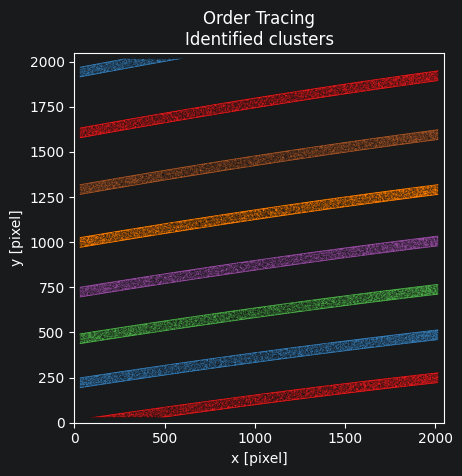

INFO - Fitting polynomials to 8 clusters
INFO - Assigned order/fiber to 8 traces


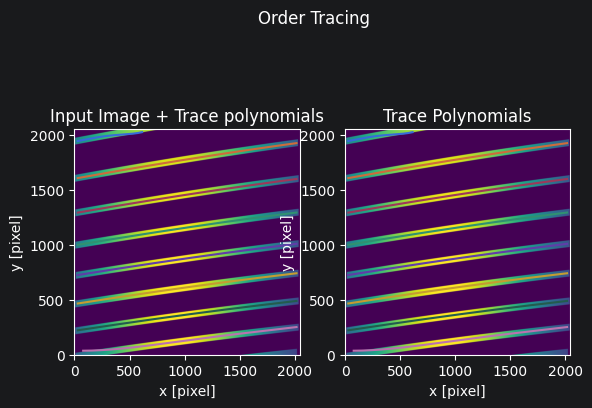

WARNING - Traces not ordered by y-position at x=322: trace 1 (y=1656.7) < trace 0 (y=1990.5) when saving to ../../../zs-scopesim/dev_notebooks/sims/reduced/trace_K.fits
WARNING - Traces not ordered by y-position at x=322: trace 2 (y=1341.2) < trace 1 (y=1656.7) when saving to ../../../zs-scopesim/dev_notebooks/sims/reduced/trace_K.fits
WARNING - Traces not ordered by y-position at x=322: trace 3 (y=1046.4) < trace 2 (y=1341.2) when saving to ../../../zs-scopesim/dev_notebooks/sims/reduced/trace_K.fits
WARNING - Traces not ordered by y-position at x=322: trace 4 (y=770.3) < trace 3 (y=1046.4) when saving to ../../../zs-scopesim/dev_notebooks/sims/reduced/trace_K.fits
WARNING - Traces not ordered by y-position at x=322: trace 5 (y=510.4) < trace 4 (y=770.3) when saving to ../../../zs-scopesim/dev_notebooks/sims/reduced/trace_K.fits
WARNING - Traces not ordered by y-position at x=322: trace 6 (y=265.6) < trace 5 (y=510.4) when saving to ../../../zs-scopesim/dev_notebooks/sims/reduced/trac

In [27]:
from steps import trace_wrapper
from pyreduce.trace_model import save_traces

cfg = settings_cfg.get('trace') # get settings for trace step
print(cfg)  # print to verify
# update values if needed
chan_updates = {
    'B': {'border_width':[30, 70, 200, 150], 'min_cluster':20000, 'plot':True},
    'G': {'border_width': [200, 30, 30, 30], 'min_cluster':20000, 'plot':True},
    'R': {'border_width':30, 'plot':True},
    'YJ': {'border_width': [30, 30, 100, 100], 'min_cluster':20000, 'plot':True},
    'H': {'border_width': [30, 30, 30, 30], 'min_cluster':15000, 'plot':True},
    'K': {'border_width': [30, 30, 30, 30], 'min_cluster':15000, 'plot':True},
}

traces = {}
for chan in zs.config.channels:
    chancfg = deepcopy(cfg)
    chancfg.update(chan_updates[chan])

    flat, fhead = cals[chan]['mflat']
    tr = trace_wrapper(flat, chancfg)

    traces[chan] = tr
    save_traces(f"{outdir}/trace_{chan}.fits", tr, steps=["trace"])


#### Load previously saved traces

In [9]:
# load traces
from pyreduce.trace_model import load_traces

traces = {}
for chan in zs.config.channels:
    tr, _ = load_traces(f"{outdir}/trace_{chan}.fits")
    traces[chan] = tr

INFO - Loaded 23 traces from: ../../../zs-scopesim/dev_notebooks/sims/reduced/trace_B.fits
WARNING - Traces not ordered by y-position at x=780: trace 1 (y=1825.1) < trace 0 (y=1939.0) loaded from ../../../zs-scopesim/dev_notebooks/sims/reduced/trace_B.fits
WARNING - Traces not ordered by y-position at x=780: trace 2 (y=1713.9) < trace 1 (y=1825.1) loaded from ../../../zs-scopesim/dev_notebooks/sims/reduced/trace_B.fits
WARNING - Traces not ordered by y-position at x=780: trace 3 (y=1606.2) < trace 2 (y=1713.9) loaded from ../../../zs-scopesim/dev_notebooks/sims/reduced/trace_B.fits
WARNING - Traces not ordered by y-position at x=780: trace 4 (y=1501.8) < trace 3 (y=1606.2) loaded from ../../../zs-scopesim/dev_notebooks/sims/reduced/trace_B.fits
WARNING - Traces not ordered by y-position at x=780: trace 5 (y=1400.5) < trace 4 (y=1501.8) loaded from ../../../zs-scopesim/dev_notebooks/sims/reduced/trace_B.fits
WARNING - Traces not ordered by y-position at x=780: trace 6 (y=1302.2) < trace

# Normalize flat field step

#### Run flat normalization and save output

{'extraction_method': 'normalize', 'smooth_slitfunction': 2, 'smooth_spectrum': 0, 'oversampling': 10, 'maxiter': 30, 'swath_width': 200, 'extraction_height': 0.9, 'threshold': 1000, 'threshold_lower': 0, 'extraction_reject': 6, 'plot': True, 'plot_title': 'Normalized Flat'}
INFO - Using optimal extraction to produce spectrum


Swath:  45%|████▌     | 5/11 [00:00<00:01,  4.78it/s, chi=6.78]
                                                               
Swath:  55%|█████▍    | 6/11 [00:01<00:01,  3.89it/s, chi=1.81]

WARNING - Did not finish convergence after maxiter (30) iterations



Swath:  82%|████████▏ | 9/11 [00:01<00:00,  5.83it/s, chi=1.75]
                                                               
Swath:  91%|█████████ | 10/11 [00:02<00:00,  4.77it/s, chi=329.83]

WARNING - Did not finish convergence after maxiter (30) iterations


...


Swath:  47%|████▋     | 7/15 [00:01<00:01,  6.09it/s, chi=0.18]
                                                               
Swath:  60%|██████    | 9/15 [00:01<00:01,  5.12it/s, chi=24.66]

WARNING - Did not finish convergence after maxiter (30) iterations



Swath:   0%|          | 0/13 [00:00<?, ?it/s, chi=0.28]
                                                       
Swath:  46%|████▌     | 6/13 [00:00<00:00, 19.78it/s, chi=0.16]

WARNING - Did not finish convergence after maxiter (30) iterations



Trace: 100%|██████████| 23/23 [01:19<00:00,  3.44s/it]          


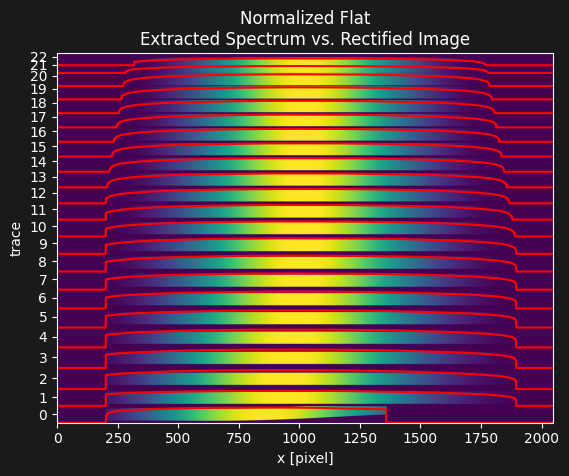

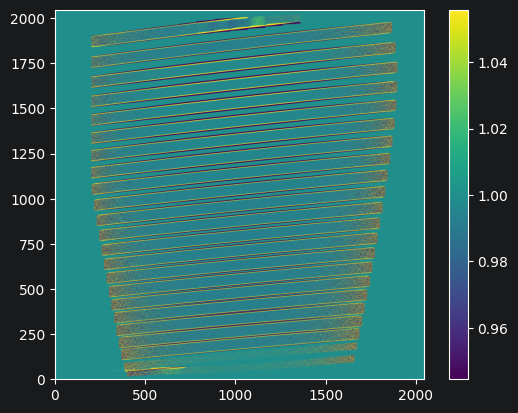

3.7147208e-07 6.345958
INFO - Using optimal extraction to produce spectrum


Swath:   7%|▋         | 1/15 [00:00<00:04,  3.10it/s, chi=19.60]
                                                                
Swath:  13%|█▎        | 2/15 [00:00<00:04,  2.72it/s, chi=34.54]

WARNING - Did not finish convergence after maxiter (30) iterations



                                                                
Swath:  20%|██        | 3/15 [00:01<00:04,  2.67it/s, chi=1453.65]

WARNING - Did not finish convergence after maxiter (30) iterations


...


                                                                  
Swath:  53%|█████▎    | 10/19 [00:03<00:03,  2.91it/s, chi=1594.72]

WARNING - Did not finish convergence after maxiter (30) iterations



Swath:  63%|██████▎   | 12/19 [00:03<00:02,  3.12it/s, chi=22.60]
                                                                 
Swath:  68%|██████▊   | 13/19 [00:04<00:01,  3.00it/s, chi=1126.98]

WARNING - Did not finish convergence after maxiter (30) iterations



Trace: 100%|██████████| 20/20 [01:15<00:00,  3.79s/it]          


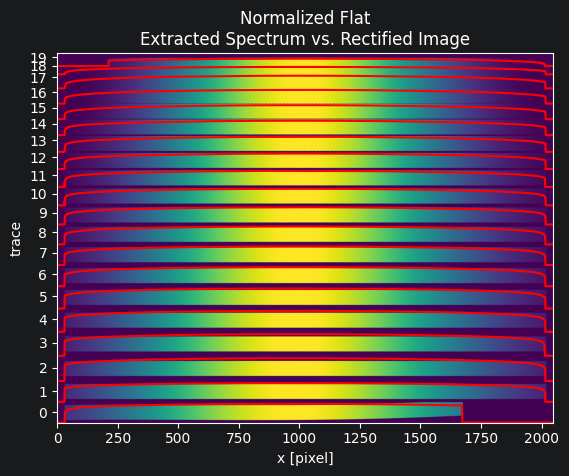

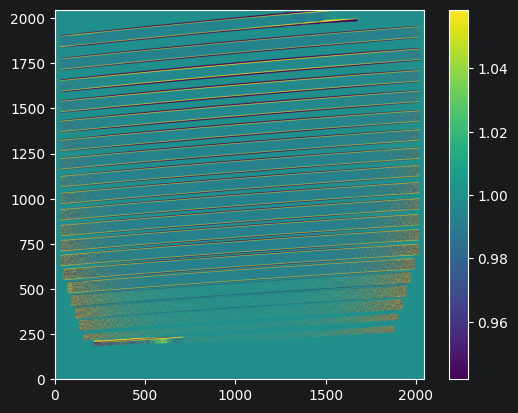

1.1301051e-08 3.7169394
INFO - Using optimal extraction to produce spectrum


Swath:  37%|███▋      | 7/19 [00:02<00:05,  2.30it/s, chi=1.09]
                                                               
Swath:  42%|████▏     | 8/19 [00:03<00:05,  2.06it/s, chi=197.77]

WARNING - Did not finish convergence after maxiter (30) iterations



Trace: 100%|██████████| 19/19 [01:12<00:00,  3.83s/it]          


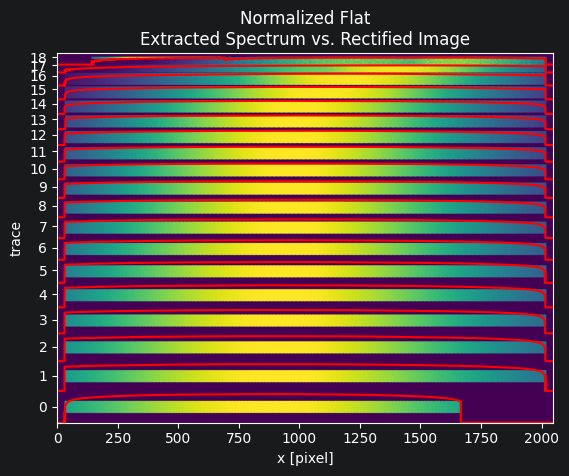

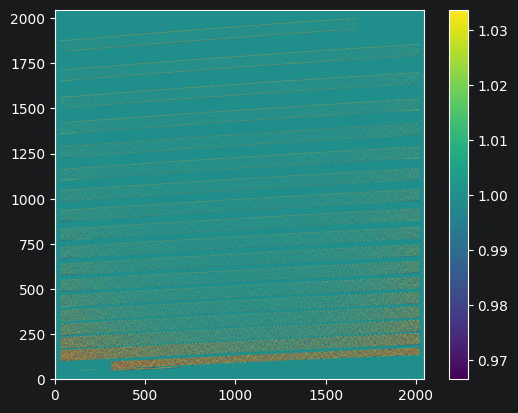

8.923694e-09 4.049779
INFO - Using optimal extraction to produce spectrum


Swath:  85%|████████▍ | 11/13 [00:02<00:00,  3.46it/s, chi=2.23]
                                                                
Swath: 100%|██████████| 13/13 [00:03<00:00,  3.59it/s, chi=3.97]
                                                                

WARNING - Did not finish convergence after maxiter (30) iterations


Swath:  47%|████▋     | 8/17 [00:01<00:02,  3.87it/s, chi=77.79]
                                                                
Swath:  53%|█████▎    | 9/17 [00:02<00:02,  3.28it/s, chi=712.68]

WARNING - Did not finish convergence after maxiter (30) iterations



Swath:  41%|████      | 7/17 [00:01<00:02,  4.41it/s, chi=33.98]
                                                                
Swath:  47%|████▋     | 8/17 [00:01<00:02,  3.73it/s, chi=1.34]

WARNING - Did not finish convergence after maxiter (30) iterations



                                                               
Swath:  53%|█████▎    | 9/17 [00:01<00:02,  3.35it/s, chi=55.79]

WARNING - Did not finish convergence after maxiter (30) iterations



Trace: 100%|██████████| 22/22 [01:11<00:00,  3.25s/it]          


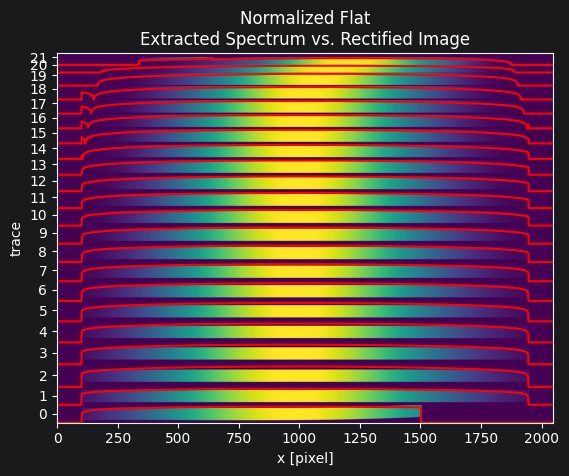

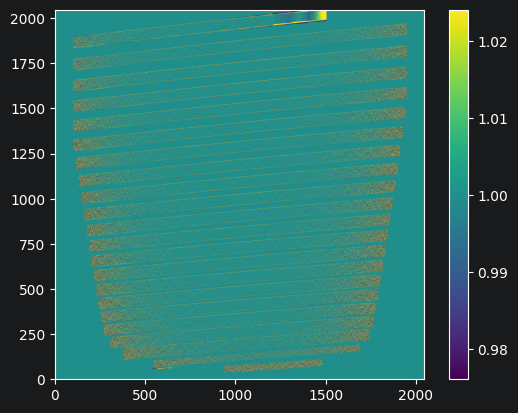

5.1175904e-09 19.728027
INFO - Using optimal extraction to produce spectrum


Swath:  36%|███▋      | 4/11 [00:02<00:05,  1.32it/s, chi=55.33]
                                                                
Swath:  45%|████▌     | 5/11 [00:03<00:04,  1.22it/s, chi=174.90]

WARNING - Did not finish convergence after maxiter (30) iterations



                                                                 
Swath:  55%|█████▍    | 6/11 [00:04<00:04,  1.17it/s, chi=438.19]

WARNING - Did not finish convergence after maxiter (30) iterations


...


Swath:  42%|████▏     | 8/19 [00:04<00:06,  1.80it/s, chi=0.39]
                                                               
Swath:  47%|████▋     | 9/19 [00:04<00:05,  1.72it/s, chi=109.83]

WARNING - Did not finish convergence after maxiter (30) iterations



Swath:  84%|████████▍ | 16/19 [00:08<00:01,  1.88it/s, chi=52.64]
                                                                 
Swath:  89%|████████▉ | 17/19 [00:09<00:01,  1.72it/s, chi=56.25]

WARNING - Did not finish convergence after maxiter (30) iterations



Trace: 100%|██████████| 10/10 [01:45<00:00, 10.59s/it]         


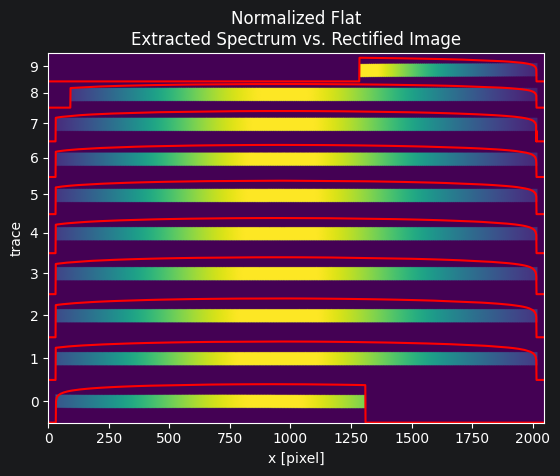

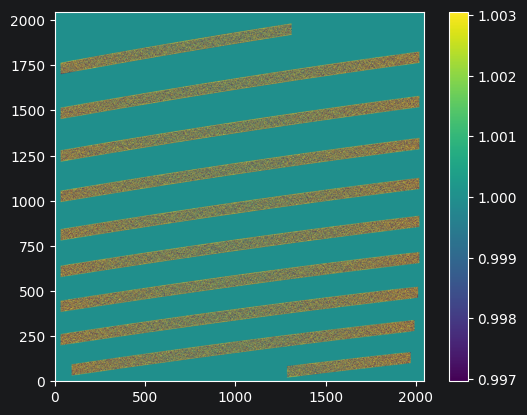

3.3765812e-09 5.733313
WARNING - No columns are completely within the specified height for trace 0, removing it.
INFO - Using optimal extraction to produce spectrum


Swath:   6%|▌         | 1/17 [00:01<00:17,  1.09s/it, chi=32.76]
                                                                
Swath:  12%|█▏        | 2/17 [00:02<00:17,  1.20s/it, chi=550.70]

WARNING - Did not finish convergence after maxiter (30) iterations



                                                                 
Swath:  18%|█▊        | 3/17 [00:03<00:17,  1.22s/it, chi=63.46]

WARNING - Did not finish convergence after maxiter (30) iterations


...


Swath:  31%|███       | 4/13 [00:02<00:05,  1.64it/s, chi=75.20]
                                                                
Swath:  38%|███▊      | 5/13 [00:03<00:05,  1.57it/s, chi=345.05]

WARNING - Did not finish convergence after maxiter (30) iterations



                                                                 
Swath:  46%|████▌     | 6/13 [00:03<00:04,  1.54it/s, chi=118.81]

WARNING - Did not finish convergence after maxiter (30) iterations



Trace: 100%|██████████| 7/7 [02:05<00:00, 17.99s/it]            


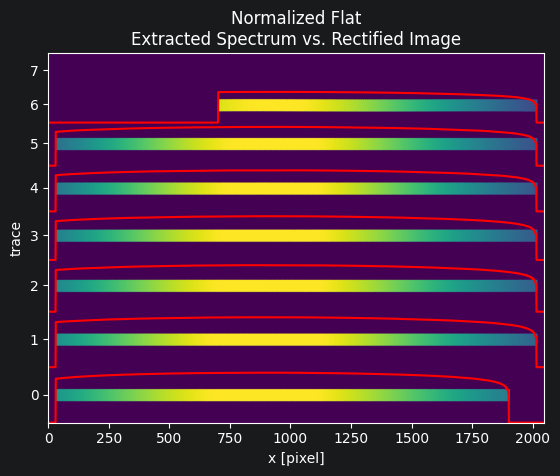

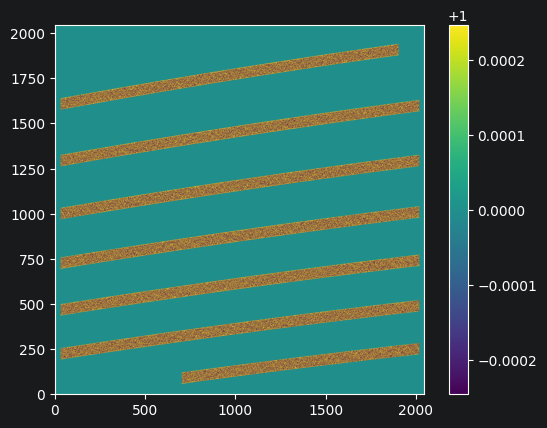

4.050896e-09 2.5942643


In [24]:
from steps import normflat_wrapper
from astropy.visualization import ZScaleInterval

settings_cfg = config_loader('ZSHOOTER/settings.yaml')
cfg = settings_cfg.get('norm_flat')
print(cfg)
# cfg['maxiter'] = 10
chan_updates = {
    'B': {'plot':True, 'threshold':100, 'extraction_height':1.001, 'smooth_slitfunction':1000},
    'G': {'plot':True, 'threshold':100, 'extraction_height':0.9, 'smooth_slitfunction':1000},
    'R': {'plot':True, 'threshold':50, 'extraction_height':1.001},
    'YJ': {'plot':True, 'threshold':1000, 'extraction_height':1.001, 'snooth_slitfnction':1000},
    'H': {'plot':True, 'threshold':5000, 'extraction_height':0.9, 'snooth_slitfnction':1000},
    'K': {'plot':True, 'threshold':5000, 'extraction_height':0.9, 'snooth_slitfnction':1000},
}

for chan in zs.config.channels:
    chancfg = deepcopy(cfg)
    chancfg.update(chan_updates[chan])

    flat, fhead = cals[chan]['mflat']
    norm, blaze, slitfunc, slitfunc_meta = normflat_wrapper(flat, fhead, traces[chan], chancfg)

    cals[chan]['norm'] = norm  ## add it to cals dict
    np.savez(f"{outdir}/norm_{chan}.npz", norm=norm, blaze=blaze, slitfunc=np.array(slitfunc, dtype=object),
             slitfunc_meta=slitfunc_meta)

    if chancfg['plot']:
        z = ZScaleInterval()
        vmin, vmax = z.get_limits(norm)
        plt.imshow(norm, origin='lower', vmin=vmin, vmax=vmax)
        plt.colorbar()
        plt.show()
        print(norm.min(), norm.max())

#### Load previously created norm flat

In [10]:
for chan in zs.config.channels:
    normfile = f"{outdir}/norm_{chan}.npz"
    nf = np.load(normfile, allow_pickle=True)
    cals[chan]['norm'] = nf['norm']
    cals[chan]['blaze'] = nf['blaze']

# Science extraction step

WARNING - No exposure time set in bias, using number of files instead
INFO - Found 60 clusters initially
INFO - Removed 35 clusters smaller than min_cluster=5000, 24 remain


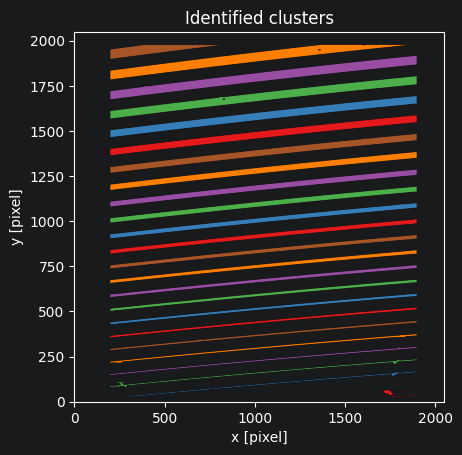

INFO - Removed 1 clusters narrower than min_width=409, 23 remain
INFO - Fitting polynomials to 23 clusters
INFO - Assigned order/fiber to 23 traces
INFO -   Order numbers (m): [22, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]


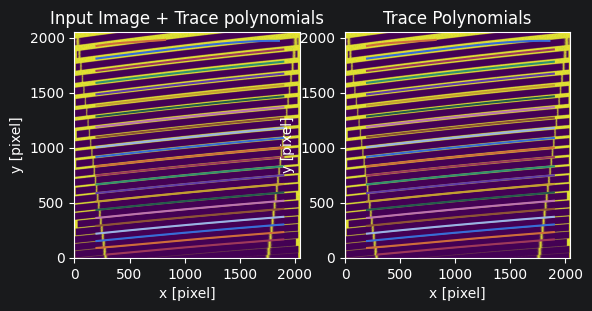

INFO - Using optimal extraction to produce spectrum


Trace:   0%|          | 0/23 [00:00<?, ?it/s]
                                             [A
Swath:  33%|███▎      | 1/3 [00:00<00:00,  2.21it/s, chi=0.16]

WARNING - Did not finish convergence after maxiter (5) iterations


                                             
Swath:  67%|██████▋   | 2/3 [00:00<00:00,  2.54it/s, chi=0.19]

WARNING - Did not finish convergence after maxiter (5) iterations


...

WARNING - Did not finish convergence after maxiter (5) iterations


                                                      
Swath:  67%|██████▋   | 2/3 [00:00<00:00,  4.15it/s, chi=0.36]

WARNING - Did not finish convergence after maxiter (5) iterations


                                                      
Trace: 100%|██████████| 23/23 [00:22<00:00,  1.02it/s]         


WARNING - Did not finish convergence after maxiter (5) iterations


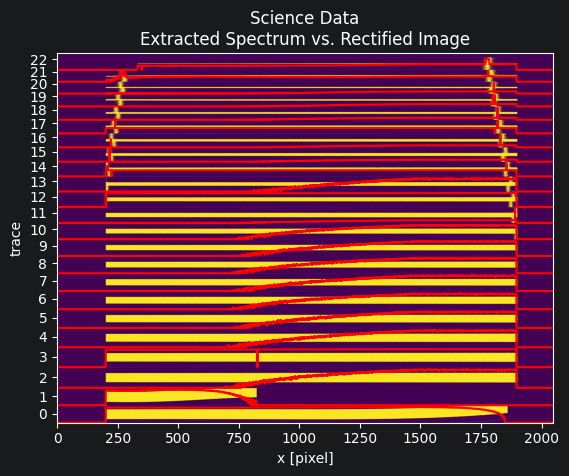

INFO - Saved 23 spectra to: ../../../zs-scopesim/dev_notebooks/sims/reduced/spec_B.fits
WARNING - No exposure time set in bias, using number of files instead
INFO - Found 66 clusters initially
INFO - Removed 40 clusters smaller than min_cluster=2000, 25 remain


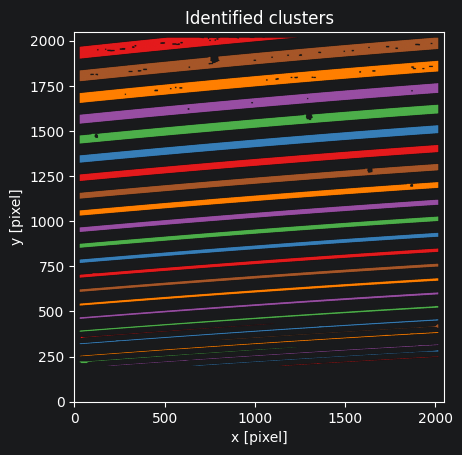

INFO - Fitting polynomials to 25 clusters
INFO - Assigned order/fiber to 25 traces
INFO -   Order numbers (m): [19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]


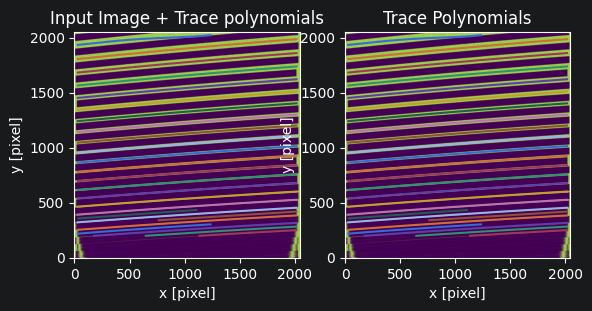

INFO - Using optimal extraction to produce spectrum


Swath:   0%|          | 0/3 [00:00<?, ?it/s]
                                                     
Swath:  33%|███▎      | 1/3 [00:00<00:01,  1.83it/s, chi=0.17]

WARNING - Did not finish convergence after maxiter (5) iterations



                                                              
Swath:  67%|██████▋   | 2/3 [00:01<00:00,  2.01it/s, chi=0.36]

WARNING - Did not finish convergence after maxiter (5) iterations


...

WARNING - Did not finish convergence after maxiter (5) iterations



                                                               
Swath:  67%|██████▋   | 2/3 [00:00<00:00,  7.92it/s, chi=10.65]

WARNING - Did not finish convergence after maxiter (5) iterations



                                                               
Trace: 100%|██████████| 25/25 [00:22<00:00,  1.11it/s]         


WARNING - Did not finish convergence after maxiter (5) iterations


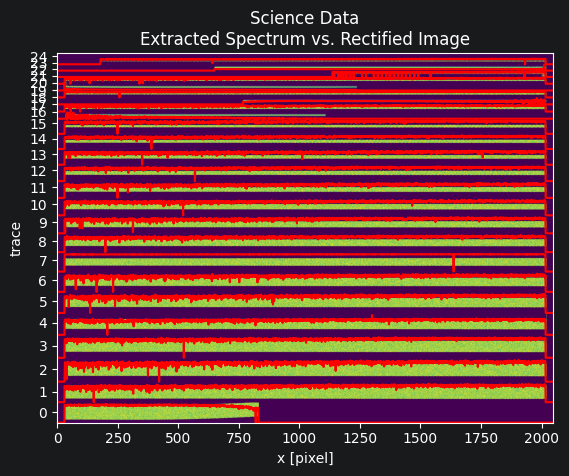

INFO - Saved 25 spectra to: ../../../zs-scopesim/dev_notebooks/sims/reduced/spec_G.fits
WARNING - No exposure time set in bias, using number of files instead
INFO - Found 67 clusters initially
INFO - Removed 48 clusters smaller than min_cluster=5000, 18 remain


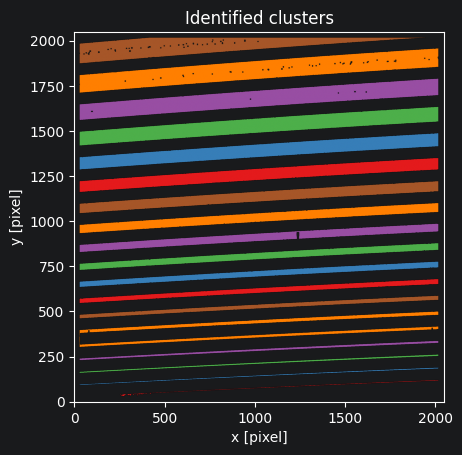

INFO - Fitting polynomials to 18 clusters
INFO - Assigned order/fiber to 18 traces
INFO -   Order numbers (m): [18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 3, 2, 1, 0]


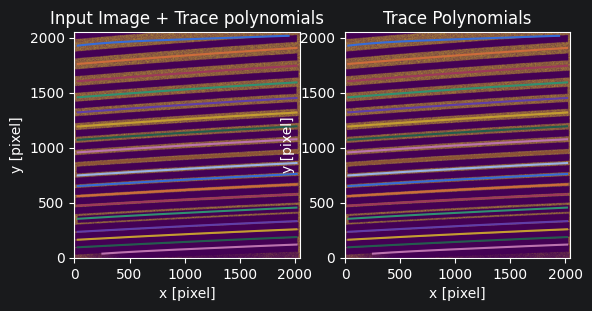

INFO - Using optimal extraction to produce spectrum


Swath:   0%|          | 0/1 [00:00<?, ?it/s]
                                             
Trace:   6%|▌         | 1/18 [00:00<00:10,  1.62it/s]         

WARNING - Did not finish convergence after maxiter (5) iterations



Swath:   0%|          | 0/3 [00:00<?, ?it/s]
                                                     
Swath:  33%|███▎      | 1/3 [00:00<00:01,  1.85it/s, chi=12.21]

WARNING - Did not finish convergence after maxiter (5) iterations


...

WARNING - Did not finish convergence after maxiter (5) iterations



                                                               
Swath:  67%|██████▋   | 2/3 [00:00<00:00,  3.60it/s, chi=73.25]

WARNING - Did not finish convergence after maxiter (5) iterations



                                                               
Trace: 100%|██████████| 18/18 [00:25<00:00,  1.43s/it]          


WARNING - Did not finish convergence after maxiter (5) iterations


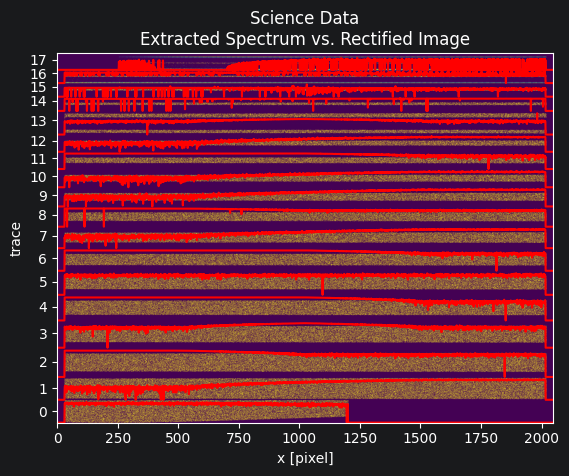

INFO - Saved 18 spectra to: ../../../zs-scopesim/dev_notebooks/sims/reduced/spec_R.fits
WARNING - No exposure time set in bias, using number of files instead
INFO - Found 62 clusters initially
INFO - Removed 39 clusters smaller than min_cluster=5000, 22 remain


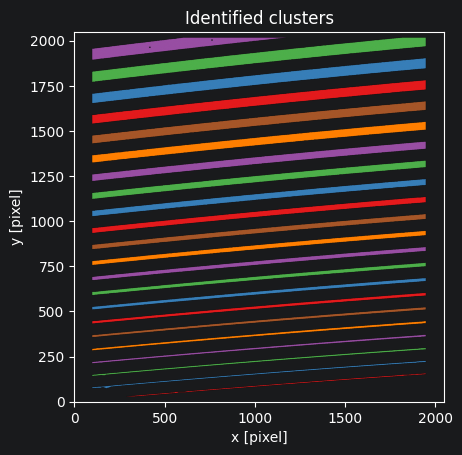

INFO - Fitting polynomials to 22 clusters
INFO - Assigned order/fiber to 22 traces
INFO -   Order numbers (m): [21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]


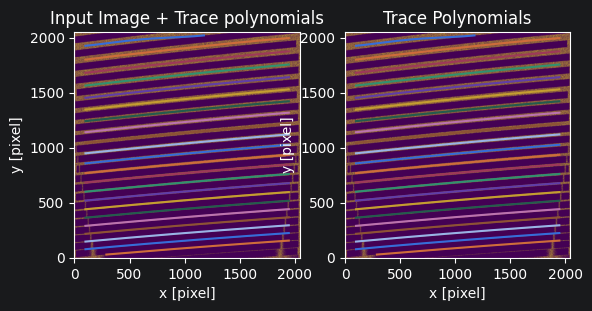

INFO - Using optimal extraction to produce spectrum


Swath:   0%|          | 0/1 [00:00<?, ?it/s]
                                             
Trace:   5%|▍         | 1/22 [00:00<00:06,  3.30it/s]         

WARNING - Did not finish convergence after maxiter (5) iterations



Swath:   0%|          | 0/3 [00:00<?, ?it/s]
                                                     
Swath:  33%|███▎      | 1/3 [00:00<00:00,  2.26it/s, chi=0.00]

WARNING - Did not finish convergence after maxiter (5) iterations


...

WARNING - Did not finish convergence after maxiter (5) iterations



                                                                
Swath:  67%|██████▋   | 2/3 [00:00<00:00,  3.94it/s, chi=199.54]

WARNING - Did not finish convergence after maxiter (5) iterations



                                                                
Trace: 100%|██████████| 22/22 [00:28<00:00,  1.28s/it]         


WARNING - Did not finish convergence after maxiter (5) iterations


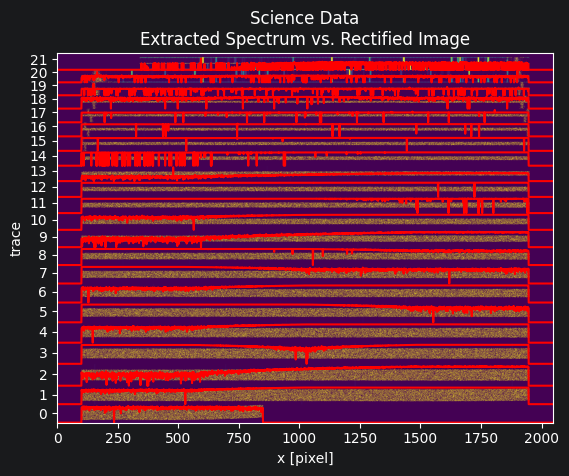

INFO - Saved 22 spectra to: ../../../zs-scopesim/dev_notebooks/sims/reduced/spec_YJ.fits
WARNING - No exposure time set in bias, using number of files instead
INFO - Found 11 clusters initially


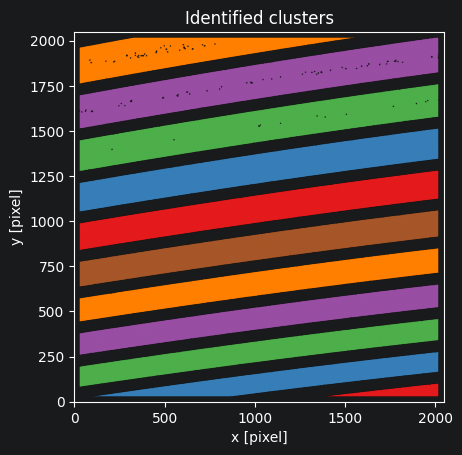

INFO - Fitting polynomials to 11 clusters
INFO - Assigned order/fiber to 11 traces
INFO -   Order numbers (m): [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]


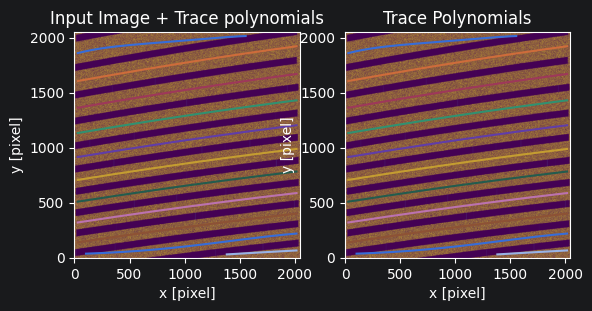

INFO - Using optimal extraction to produce spectrum


Swath:   0%|          | 0/1 [00:00<?, ?it/s]
                                             
Trace:   9%|▉         | 1/11 [00:00<00:05,  1.67it/s]         

WARNING - Did not finish convergence after maxiter (5) iterations



Swath:   0%|          | 0/3 [00:00<?, ?it/s]
                                                     
Swath:  33%|███▎      | 1/3 [00:01<00:02,  1.09s/it, chi=11.26]

WARNING - Did not finish convergence after maxiter (5) iterations


...


Swath:   0%|          | 0/1 [00:00<?, ?it/s]
                                                     
Swath:   0%|          | 0/1 [00:00<?, ?it/s, chi=10.19]
                                                       

WARNING - Did not finish convergence after maxiter (5) iterations



Swath:   0%|          | 0/3 [00:00<?, ?it/s]
                                                     
Swath:  33%|███▎      | 1/3 [00:00<00:00,  2.86it/s, chi=0.01]

WARNING - Did not finish convergence after maxiter (5) iterations



Trace: 100%|██████████| 11/11 [00:22<00:00,  2.02s/it]        


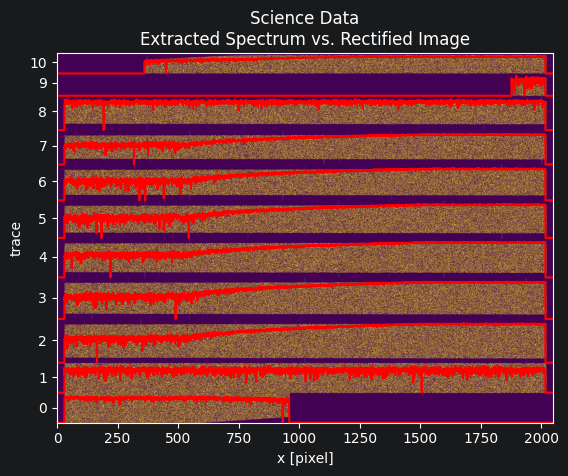

INFO - Saved 11 spectra to: ../../../zs-scopesim/dev_notebooks/sims/reduced/spec_H.fits
WARNING - No exposure time set in bias, using number of files instead
INFO - Found 9 clusters initially


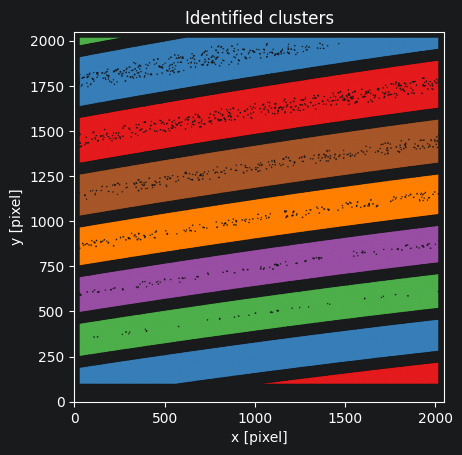

INFO - Removed 1 clusters narrower than min_width=409, 8 remain
INFO - Fitting polynomials to 8 clusters
INFO - Assigned order/fiber to 8 traces
INFO -   Order numbers (m): [6, 5, 4, 3, 2, 1, 0]


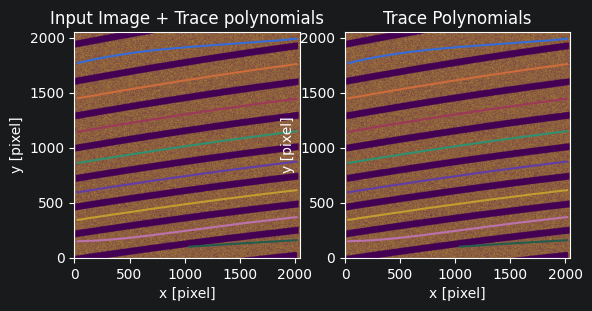

INFO - Using optimal extraction to produce spectrum


Swath:   0%|          | 0/1 [00:00<?, ?it/s]
                                            
Trace:  12%|█▎        | 1/8 [00:01<00:10,  1.46s/it]          

WARNING - Did not finish convergence after maxiter (5) iterations



Swath:   0%|          | 0/3 [00:00<?, ?it/s]
                                                    
Swath:  33%|███▎      | 1/3 [00:01<00:02,  1.34s/it, chi=10.34]

WARNING - Did not finish convergence after maxiter (5) iterations


...


Swath:   0%|          | 0/1 [00:00<?, ?it/s]
                                                    
Trace:  88%|████████▊ | 7/8 [00:19<00:02,  2.65s/it]          

WARNING - Did not finish convergence after maxiter (5) iterations



Swath:   0%|          | 0/3 [00:00<?, ?it/s]
                                                    
Swath:  33%|███▎      | 1/3 [00:00<00:01,  1.33it/s, chi=0.00]

WARNING - Did not finish convergence after maxiter (5) iterations



Trace: 100%|██████████| 8/8 [00:20<00:00,  2.60s/it]          


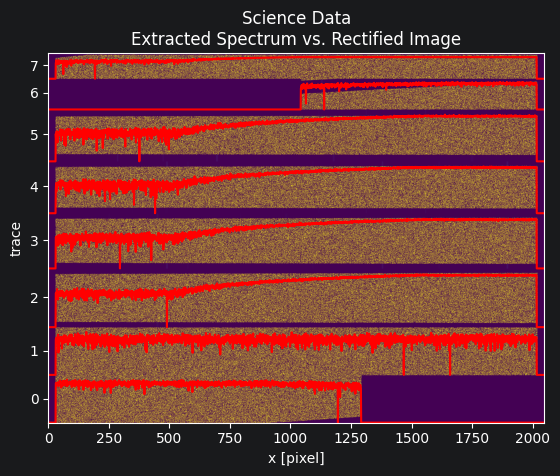

INFO - Saved 8 spectra to: ../../../zs-scopesim/dev_notebooks/sims/reduced/spec_K.fits


In [11]:
from steps import science_wrapper

settings_cfg = config_loader('ZSHOOTER/settings.yaml')
# load tracing settings for science data
tr_cfg = settings_cfg.get('trace_sci')
# load extract settings for science data
sc_cfg = settings_cfg.get('science')

# dicts for channel-wise settings
tr_chan_updates = {
    'B': {'border_width':[30, 70, 200, 150], 'filter_y':10, 'filter_x':10, 'plot':True},
    'G': {'border_width': [200, 30, 30, 30], 'filter_y':10, 'filter_x':10, 'min_cluster':2000, 'plot':True},
    'R': {'border_width':30, 'filter_y':15, 'filter_x':1, 'plot':True},
    'YJ': {'border_width': [30, 30, 100, 100], 'filter_y':10, 'filter_x':10, 'plot':True},
    'H': {'border_width': [30, 30, 30, 30], 'filter_y':30, 'filter_x':1, 'plot':True},
    'K': {'border_width': [100, 30, 30, 30], 'filter_y':30, 'filter_x':1, 'plot':True},
}

sc_chan_updates = {
    'B': {'maxiter':5},
    'G': {'maxiter':5},
    'R': {'maxiter':5},
    'YJ': {'maxiter':5},
    'H': {'maxiter':5},
    'K': {'maxiter':5}
}

spectra = {}
for chan in zs.config.channels:
    tr_chancfg = deepcopy(tr_cfg)
    tr_chancfg.update(tr_chan_updates[chan])
    sc_chancfg = deepcopy(sc_cfg)
    sc_chancfg.update(sc_chan_updates[chan])

    # run tracing
    order_centers = {t.m : t.y_at_x(1024) for t in traces[chan]}
    spec = science_wrapper(files[chan]['star'], instrument=zs, channel=chan, bias=cals[chan]['mbias'][0],
                                    bhead=cals[chan]['mbias'][1], norm=cals[chan]['mflat'][0], order_centers=order_centers,
                                    trace_step_cfg=tr_chancfg, sci_step_cfg=sc_chancfg)
    spectra[chan] = spec
    spec.save(f"{outdir}/spec_{chan}.fits", steps=["science"])


# Curvature step

In [ ]:
config = config_loader('ZSHOOTER/settings.yaml')
ccfg = config.get('curvature')
ccfg

In [ ]:
arc_files = sorted(glob.glob('../../../zs-scopesim/dev_notebooks/sims/arcs_B*.fits'))
arc, ahead = combine_calibrate(arc_files, instrument=zs, channel=channel, bias=bias, bhead=bhead)

from pyreduce.slit_curve import Curvature
curvmod = Curvature(traces=traces,
                    curve_height=ccfg['curve_height'],
                    extraction_height=ccfg['extraction_height'],
                    trace_range=None,
                    fit_degree=ccfg['degree'],
                    curve_degree=ccfg['curve_degree'],
                    sigma_cutoff=ccfg['curvature_cutoff'],
                    mode=ccfg['dimensionality'],
                    peak_threshold=ccfg['peak_threshold'],
                    peak_width=ccfg['peak_width'],
                    window_width=ccfg['window_width'],
                    peak_function=ccfg['peak_function'],
                    plot=True,
                    plot_title=None)
curvature = curvmod.execute(arc)
# Update traces in-place with curvature data
fitted_coeffs = curvature["fitted_coeffs"]
slitdeltas = curvature["slitdeltas"]
for i, t in enumerate(traces):
    if fitted_coeffs is not None and i < fitted_coeffs.shape[0]:
        t.slit = fitted_coeffs[i]
    if slitdeltas is not None and i < slitdeltas.shape[0]:
        t.slitdelta = slitdeltas[i]